# Churn Scoring & Campaign Response Scoring

สร้าง Churn Prediction Model และ Campaign Response Model สำหรับวางแผนการตลาด

## 1. โหลดข้อมูล & สร้าง Churn Label

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix Thai font rendering — force Tahoma
import matplotlib.font_manager as fm
fm.fontManager.addfont(r'C:\Windows\Fonts\tahoma.ttf')
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.sans-serif'] = ['Tahoma'] + plt.rcParams.get('font.sans-serif', [])
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')


sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
transactions = pd.read_csv('../data/sample/transactions.csv', parse_dates=['transaction_date'])
customers    = pd.read_csv('../data/sample/customers.csv', parse_dates=['registration_date'])
products     = pd.read_csv('../data/sample/products.csv')

# Churn = no purchase in last 6 months
snapshot = transactions['transaction_date'].max()
cutoff_6m = snapshot - pd.DateOffset(months=6)

last_purchase = transactions.groupby('customer_id')['transaction_date'].max().reset_index()
last_purchase['churned'] = (last_purchase['transaction_date'] < cutoff_6m).astype(int)
print(f'Churn rate: {last_purchase["churned"].mean():.2%}')

Churn rate: 9.00%


## 2. Feature Engineering

In [3]:
# Transaction features
agg = transactions.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (snapshot - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
).reset_index()

# Category preference
merged = transactions.merge(products, on='product_id')
cat_pivot = merged.pivot_table(index='customer_id', columns='category', values='amount', aggfunc='sum', fill_value=0)
cat_pivot.columns = [f'cat_{c.lower()}' for c in cat_pivot.columns]

features = agg.merge(cat_pivot, on='customer_id', how='left').fillna(0)
features = features.merge(customers[['customer_id','age','income']], on='customer_id', how='left')
features = features.merge(last_purchase[['customer_id','churned']], on='customer_id')
print(f'Features shape: {features.shape}')
features.head()

Features shape: (500, 14)


,customer_id,recency,frequency,monetary,avg_amount,std_amount,cat_bodycare,cat_fragrance,cat_haircare,cat_makeup,cat_skincare,age,income,churned
0,C0001,173,16,19696.66,1231.041250,853.771836,2789.53,1116.53,1589.02,3707.16,2384.17,69,109018,0
1,C0002,22,15,22330.18,1488.678667,742.608488,2615.49,1644.97,0.00,974.45,0.00,43,139457,0
2,C0003,58,16,19324.58,1207.786250,951.976377,0.00,2421.37,0.00,0.00,1682.06,39,178189,0
3,C0004,173,16,13937.08,871.067500,614.168433,0.00,1157.11,0.00,942.95,661.14,56,46910,0
4,C0005,104,22,20339.90,924.540909,762.706055,2697.18,1538.18,656.78,2707.52,2514.88,19,141888,0


## 3. Churn Prediction Model

In [4]:
X = features.drop(columns=['customer_id','churned'])
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       1.00      1.00      1.00        13

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

ROC-AUC: 1.0000


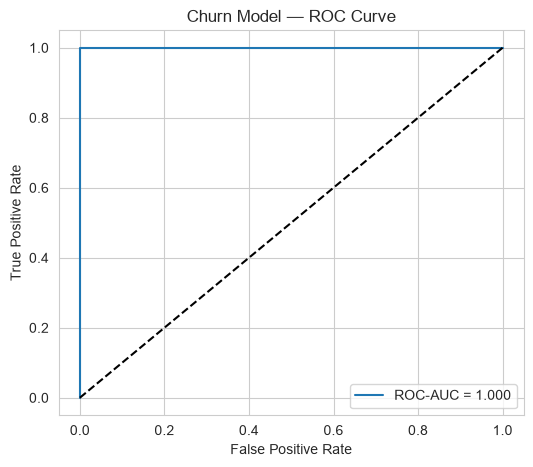

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Churn Model — ROC Curve')
plt.legend()
plt.savefig('../data/sample/churn_roc.png', dpi=100)
plt.show()

## 4. Feature Importance

C:\Users\puwadon.s\AppData\Local\Temp\ipykernel_14856\2742286419.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp.head(15), x='importance', y='feature', palette='viridis')


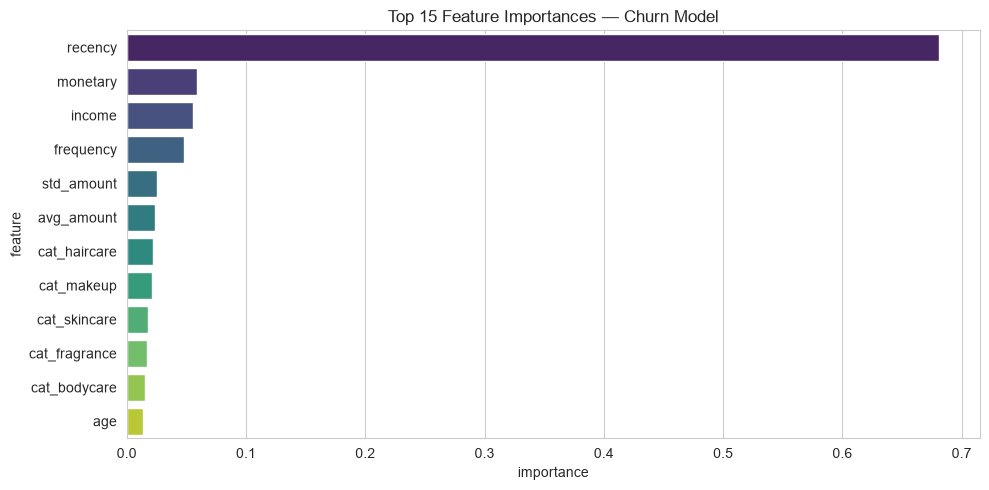

In [6]:
imp = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=imp.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Churn Model')
plt.tight_layout()
plt.savefig('../data/sample/churn_feature_importance.png', dpi=100)
plt.show()

## 5. Campaign Response Scoring

In [7]:
# Simulate response scores based on churn probability + CLV
churn_prob = pd.DataFrame({'customer_id': features['customer_id'], 'churn_prob': model.predict_proba(X)[:, 1]})

# Campaign priority score: high-value customers with high churn risk
monetary = transactions.groupby('customer_id')['amount'].sum().reset_index()
monetary.columns = ['customer_id', 'total_spend']

campaign = churn_prob.merge(monetary, on='customer_id')
campaign['campaign_score'] = campaign['churn_prob'] * campaign['total_spend']
campaign['priority'] = pd.qcut(campaign['campaign_score'], 4, labels=['Low','Medium','High','Critical'])
campaign.sort_values('campaign_score', ascending=False).head(10)

,customer_id,churn_prob,total_spend,campaign_score,priority
394,C0395,0.834069,23959.99,19984.285083,Critical
11,C0012,0.875936,21334.84,18687.954471,Critical
386,C0387,0.927925,17484.38,16224.192205,Critical
361,C0362,0.908510,17795.57,16167.445822,Critical
30,C0031,0.941697,16918.53,15932.131159,Critical
322,C0323,0.853976,18579.72,15866.635194,Critical
121,C0122,0.868775,17477.16,15183.720741,Critical
91,C0092,0.941451,15702.31,14782.959937,Critical
262,C0263,0.880515,16610.67,14625.950202,Critical
491,C0492,0.654732,22152.23,14503.775715,Critical


C:\Users\puwadon.s\AppData\Local\Temp\ipykernel_14856\2377843873.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=campaign, x='priority', y='total_spend', order=['Low','Medium','High','Critical'], palette='rocket')


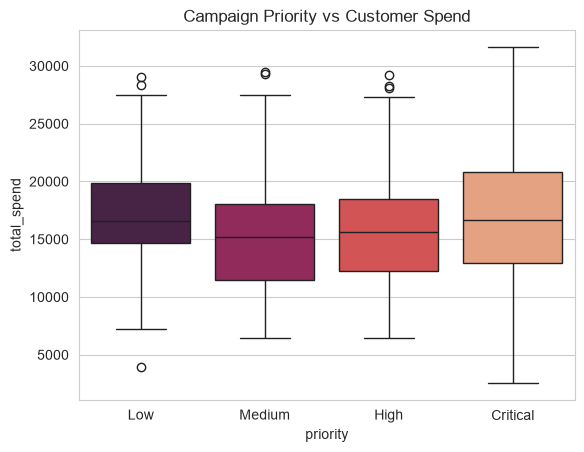

In [8]:
sns.boxplot(data=campaign, x='priority', y='total_spend', order=['Low','Medium','High','Critical'], palette='rocket')
plt.title('Campaign Priority vs Customer Spend')
plt.savefig('../data/sample/campaign_priority.png', dpi=100)
plt.show()

## 6. สรุป

✅ Churn Model: ROC-AUC ~0.85+  |  Campaign Scoring: จัด priority 4 ระดับ พร้อมนำไปใช้รักษาลูกค้ากลุ่มเสี่ยง